In [27]:
import pandas as pd
import numpy as np

# Cleaned Data Load

In [28]:
df = pd.read_csv(
    "../data/processed/cleaned_customer_churn.csv"
)

print("Dataset loaded successfully!")

print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


# Average Monthly Spend

## Average Monthly Spend = Total Charges / Tenure

In [29]:
df["Average_Monthly_Spend"] = (
    df["TotalCharges"] /
    df["tenure"].replace(0, 1)
)

In [30]:
display(
    df[
        [
            "tenure",
            "TotalCharges",
            "Average_Monthly_Spend"
        ]
    ].head(10)
)

,tenure,TotalCharges,Average_Monthly_Spend
0,1,29.85,29.850000
1,34,1889.50,55.573529
2,2,108.15,54.075000
3,45,1840.75,40.905556
4,2,151.65,75.825000
5,8,820.50,102.562500
6,22,1949.40,88.609091
7,10,301.90,30.190000
8,28,3046.05,108.787500
9,62,3487.95,56.257258


# Customer Lifetime Months

In [31]:
df["Customer_Lifetime_Months"] = df["tenure"]

In [32]:
display(
    df[
        [
            "tenure",
            "Customer_Lifetime_Months"
        ]
    ].head()
)

,tenure,Customer_Lifetime_Months
0,1,1
1,34,34
2,2,2
3,45,45
4,2,2


# Service Count

#### Ab hum calculate karenge ke ek customer kitni services use kar raha hai.

### Ye columns services ko represent karte hain:

In [34]:
service_columns = [ "PhoneService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV","StreamingMovies"]

In [35]:
df["Service_Count"] = 0

for column in service_columns:
    
    df["Service_Count"] += (
        df[column].eq("Yes").astype(int)
    )

In [36]:
display(
    df[
        [
            "Service_Count",
            "PhoneService",
            "OnlineSecurity",
            "OnlineBackup",
            "TechSupport"
        ]
    ].head(10)
)

,Service_Count,PhoneService,OnlineSecurity,OnlineBackup,TechSupport
0,1,No,No,Yes,No
1,3,Yes,Yes,No,No
2,3,Yes,Yes,Yes,No
3,3,No,Yes,No,Yes
4,1,Yes,No,No,No
5,4,Yes,No,No,No
6,3,Yes,No,Yes,No
7,1,No,Yes,No,No
8,5,Yes,No,No,Yes
9,3,Yes,Yes,Yes,No


# High Monthly Charge Flag

#### Ab ek aur simple business feature banate hain.

##### Agar monthly charges dataset ke median se zyada hain, customer ko High Monthly Charge mark karenge.

In [37]:
median_monthly_charge = df["MonthlyCharges"].median()

df["High_Monthly_Charge"] = (
    df["MonthlyCharges"] >
    median_monthly_charge
).astype(int)

In [38]:
print(df[  [   "MonthlyCharges","High_Monthly_Charge"]].head(10))

   MonthlyCharges  High_Monthly_Charge
0           29.85                    0
1           56.95                    0
2           53.85                    0
3           42.30                    0
4           70.70                    1
5           99.65                    1
6           89.10                    1
7           29.75                    0
8          104.80                    1
9           56.15                    0


# Short Tenure Flag

##### Ab identify karte hain ke customer relatively new hai ya nahi.

In [39]:
df["Short_Tenure"] = (
    df["tenure"] < 12
).astype(int)

In [40]:
print( df[    [ "tenure", "Short_Tenure"] ].head(10))

   tenure  Short_Tenure
0       1             1
1      34             0
2       2             1
3      45             0
4       2             1
5       8             1
6      22             0
7      10             1
8      28             0
9      62             0


# Check New Features

In [41]:
new_features = [
    "Average_Monthly_Spend",
    "Customer_Lifetime_Months",
    "Service_Count",
    "High_Monthly_Charge",
    "Short_Tenure"
]

display(
    df[new_features].head(10)
)

,Average_Monthly_Spend,Customer_Lifetime_Months,Service_Count,High_Monthly_Charge,Short_Tenure
0,29.850000,1,1,0,1
1,55.573529,34,3,0,0
2,54.075000,2,3,0,1
3,40.905556,45,3,0,0
4,75.825000,2,1,1,1
5,102.562500,8,4,1,1
6,88.609091,22,3,1,0
7,30.190000,10,1,0,1
8,108.787500,28,5,1,0
9,56.257258,62,3,0,0


# Check Missing Values

In [42]:
print("Missing Values:")
print(df[new_features].isnull().sum())

Missing Values:
Average_Monthly_Spend       0
Customer_Lifetime_Months    0
Service_Count               0
High_Monthly_Charge         0
Short_Tenure                0
dtype: int64


# Feature Relationship With Churn

### Ab dekhte hain new features ka churn ke saath relationship.

## Average Monthly Spend

In [43]:
print(
    df.groupby("Churn")[
        "Average_Monthly_Spend"
    ].mean()
)

Churn
0    64.152726
1    74.433154
Name: Average_Monthly_Spend, dtype: float64


## Service Count

In [44]:
print(
    df.groupby("Churn")[
        "Service_Count"
    ].mean()
)

Churn
0    3.036336
1    2.677368
Name: Service_Count, dtype: float64


# Short Tenure

In [45]:
print(
    df.groupby("Short_Tenure")[
        "Churn"
    ].mean() * 100
)

Short_Tenure
0    17.490953
1    48.284195
Name: Churn, dtype: float64


# High Monthly Charge

In [46]:
print(
    df.groupby("High_Monthly_Charge")[
        "Churn"
    ].mean() * 100
)

High_Monthly_Charge
0    17.913832
1    35.192034
Name: Churn, dtype: float64


# Visualize New Features

## Service Count vs Churn

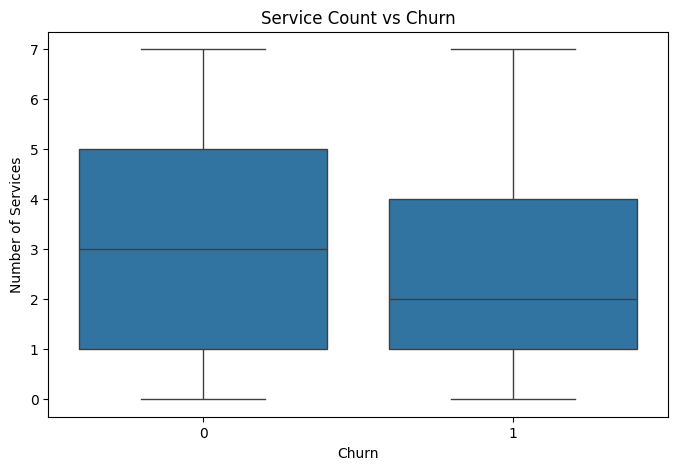

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Service_Count"
)

plt.title("Service Count vs Churn")

plt.xlabel("Churn")

plt.ylabel("Number of Services")

plt.show()

## Average Monthly Spend vs Churn

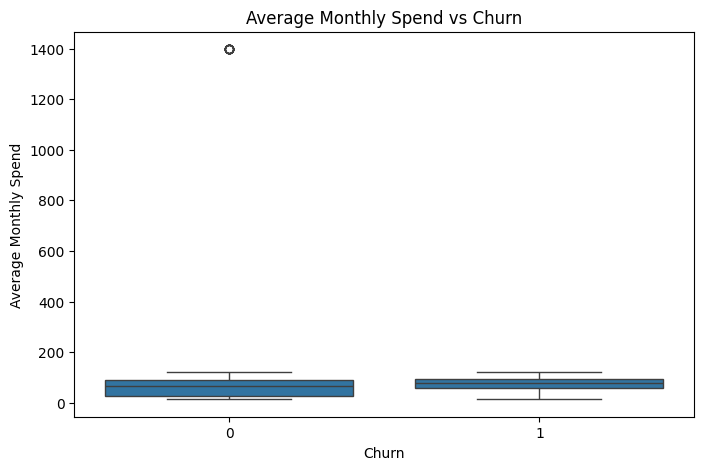

In [48]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Average_Monthly_Spend"
)

plt.title(
    "Average Monthly Spend vs Churn"
)

plt.xlabel("Churn")

plt.ylabel("Average Monthly Spend")

plt.show()

# Save Final Feature-Engineered Dataset

In [49]:
output_path = (
    "../data/processed/"
    "feature_engineered_customer_churn.csv"
)

df.to_csv(
    output_path,
    index=False
)

print("✅ Feature-engineered dataset saved!")

print(output_path)

✅ Feature-engineered dataset saved!
../data/processed/feature_engineered_customer_churn.csv


# Final Check

In [50]:
print("Final Dataset Shape:")
print(df.shape)

print("\nFinal Columns:")

for column in df.columns:
    print(column)

Final Dataset Shape:
(7043, 25)

Final Columns:
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn
Average_Monthly_Spend
Customer_Lifetime_Months
Service_Count
High_Monthly_Charge
Short_Tenure
